# **Imports**

In [1]:

from earthscape.constants import VERSION, ASSETS_DIR, MODEL_DIR
import os
import glob
import numpy as np
import pandas as pd
from scipy.stats import t
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
from matplotlib.patches import Patch
import seaborn as sns

from scipy import stats

from earthscape.analysis.data_processing import parse_input_label, parse_features, spatial_support

# **Setup**

In [2]:
#############################################
# Setup input and output directories & paths
#############################################

# directory of experiments
exp_dir = r'../experiments/baselines/classification'

# single modality experiments...
single_root = os.path.join(exp_dir, 'single')
single_dirs = glob.glob(f"{single_root}/*")

# multi-scale modality experiments...
ms_root = os.path.join(exp_dir, 'multiscale')
ms_dirs = glob.glob(f"{ms_root}/*")

# multimodal experiments modalities...
mm_root = os.path.join(exp_dir, 'multimodal')
mm_dirs = glob.glob(f"{mm_root}/*")

# output directory for visualizations...
assets_dir = os.path.join(exp_dir.replace(MODEL_DIR, ASSETS_DIR))
if not os.path.isdir(assets_dir):
    os.makedirs(assets_dir)


# path to areas CSV
areas_path = glob.glob(r'../data/*areas.csv')[0]


# **Global Performance**

## *Compile Single Modality Experiments*

In [226]:
##################################################
# Compile Global Performance Metrics - Single
##################################################

# output path for global summary
output_path = os.path.join(assets_dir, 'single_global.csv')


##### compile global in- & cross-domain data...
# initialize df
df_single = pd.DataFrame(columns=['model', 'input'])

# collect global data from all experiments...
for idx, d in enumerate(single_dirs):
    
    # skip any files in root directory...
    if os.path.isfile(d):
        continue
    
    # metadata of model name & modality input...
    meta = os.path.basename(d)
    meta = meta.split('_')
    model_name = meta[0]
    modalities = meta[1]

    # in-domain...
    id_global_path = os.path.join(d, 'id_global.csv')
    id = pd.read_csv(id_global_path)
    id.columns = [col +' (id)' for col in id.columns]
    
    # cross-domain...
    cd_global_path = os.path.join(d, 'cd_global.csv')
    cd = pd.read_csv(cd_global_path)
    cd.columns = [col +' (cd)' for col in cd.columns]

    # merge datasets...
    df_single.loc[idx, 'model'] = model_name
    df_single.loc[idx, 'input'] = modalities
    df_single.loc[idx, id.columns] = id.values
    df_single.loc[idx, cd.columns] = cd.values

# save & display...
df_single.to_csv(output_path, index=False)
df_single.sort_values('macro_map (id)', ascending=False).head(10)

,model,input,macro_precision (id),macro_recall (id),macro_f1 (id),auroc (id),macro_map (id),micro_accuracy (id),macro_precision (cd),macro_recall (cd),macro_f1 (cd),auroc (cd),macro_map (cd),micro_accuracy (cd)
72,swin,ep-11,0.612383,0.697355,0.649691,0.883722,0.710338,0.857701,0.459627,0.382369,0.392702,0.697862,0.451107,0.832217
5,resnet18,ep-51,0.636786,0.686603,0.659682,0.880688,0.709268,0.864862,0.502615,0.480828,0.485217,0.754308,0.516429,0.829613
76,swin,ep-5,0.611586,0.699071,0.644183,0.882956,0.701306,0.861328,0.426486,0.432066,0.368248,0.689637,0.438316,0.803385
28,resnet18,s-5,0.624455,0.705374,0.658461,0.869064,0.700866,0.869327,0.517237,0.725862,0.598534,0.852652,0.617644,0.847098
40,resnet50,ep-51,0.585681,0.720874,0.634519,0.866216,0.700651,0.853144,0.521299,0.492932,0.489926,0.735214,0.521667,0.835007
4,resnet18,ep-21,0.637124,0.687794,0.652460,0.886925,0.699768,0.868025,0.402375,0.367022,0.369382,0.660956,0.435184,0.825335
39,resnet50,ep-21,0.593776,0.697792,0.639896,0.873412,0.697564,0.855097,0.426472,0.424050,0.410912,0.659939,0.445276,0.815941
36,resnet50,ep-101,0.589596,0.703334,0.635583,0.867393,0.692242,0.850260,0.455514,0.567533,0.499525,0.757239,0.524425,0.814360
98,swin,s-5,0.603884,0.768907,0.654084,0.868813,0.691055,0.856585,0.500588,0.713155,0.578801,0.796025,0.582586,0.835193
6,resnet18,ep-5,0.628201,0.697079,0.658645,0.879461,0.689533,0.861979,0.366721,0.406409,0.368388,0.603635,0.408562,0.792504


## *Compile Multi-scale Experiments*

In [227]:
##################################################
# Compile Global Performance Metrics - Multi-scale
##################################################

# output path for global summary
output_path = os.path.join(assets_dir, 'multiscale_global.csv')


##### compile global in- & cross-domain data...
# initialize df
df_ms = pd.DataFrame(columns=['model', 'input'])

# collect global data from all experiments...
for idx, d in enumerate(ms_dirs):
    
    # skip any files in root directory...
    if os.path.isfile(d):
        continue
    
    # metadata of model name & modality input...
    meta = os.path.basename(d)
    meta = meta.split('_')
    model_name = meta[0]
    modalities = meta[1]

    # in-domain...
    id_global_path = os.path.join(d, 'id_global.csv')
    id = pd.read_csv(id_global_path)
    id.columns = [col +' (id)' for col in id.columns]
    
    # cross-domain...
    cd_global_path = os.path.join(d, 'cd_global.csv')
    cd = pd.read_csv(cd_global_path)
    cd.columns = [col +' (cd)' for col in cd.columns]

    # merge datasets...
    df_ms.loc[idx, 'model'] = model_name
    df_ms.loc[idx, 'input'] = modalities
    df_ms.loc[idx, id.columns] = id.values
    df_ms.loc[idx, cd.columns] = cd.values

# save & display...
df_ms.to_csv(output_path, index=False)
df_ms.sort_values('macro_map (id)', ascending=False).head(10)

,model,input,macro_precision (id),macro_recall (id),macro_f1 (id),auroc (id),macro_map (id),micro_accuracy (id),macro_precision (cd),macro_recall (cd),macro_f1 (cd),auroc (cd),macro_map (cd),micro_accuracy (cd)
10,swin,ep-ms,0.653678,0.704565,0.676589,0.897386,0.729474,0.879464,0.528149,0.703011,0.591653,0.867399,0.639407,0.859282
2,resnet18,prc-ms,0.653658,0.701854,0.664650,0.905623,0.727501,0.883650,0.551286,0.666225,0.599876,0.799561,0.629986,0.870350
0,resnet18,ep-ms,0.649184,0.710851,0.670324,0.903797,0.719905,0.877511,0.528758,0.553824,0.519121,0.787620,0.542365,0.843378
13,swin,s-ms,0.619343,0.773864,0.666862,0.889830,0.711258,0.863746,0.518991,0.683608,0.584668,0.821157,0.602744,0.850911
3,resnet18,s-ms,0.632823,0.737827,0.672458,0.884698,0.709102,0.874907,0.502245,0.671046,0.566459,0.797132,0.607162,0.845145
1,resnet18,plc-ms,0.633666,0.754978,0.676541,0.882308,0.706658,0.855655,0.480477,0.714206,0.563645,0.821300,0.587493,0.808594
5,resnet50,ep-ms,0.639121,0.684156,0.654594,0.881472,0.706510,0.868862,0.525052,0.608081,0.554393,0.798113,0.580486,0.850911
12,swin,prc-ms,0.602074,0.747292,0.649716,0.900576,0.702681,0.861514,0.510747,0.681785,0.577896,0.803661,0.612337,0.845331
7,resnet50,prc-ms,0.618583,0.715491,0.656155,0.903007,0.702324,0.871094,0.509224,0.642402,0.564026,0.767270,0.606533,0.860398
8,resnet50,s-ms,0.628439,0.735178,0.664906,0.886234,0.691814,0.872210,0.540895,0.683488,0.600045,0.823301,0.620681,0.860770


## *Compile Multimodal Experiments*

In [228]:
##################################################
# Compile Global Performance Metrics - Multimodal
##################################################

# output path for global summary
output_path = os.path.join(assets_dir, 'multimodal_global.csv')


##### compile global in- & cross-domain data...
# initialize df
df_mm = pd.DataFrame(columns=['model', 'input'])

# collect global data from all experiments...
for idx, d in enumerate(mm_dirs):
    
    # skip any files in root directory...
    if os.path.isfile(d):
        continue
    
    # metadata of model name & modality input...
    meta = os.path.basename(d)
    meta = meta.split('_')
    model_name = meta[0]
    modalities = meta[1]
    if modalities == 'dem':
        modalities = 'dem+rgb'

    # in-domain...
    id_global_path = os.path.join(d, 'id_global.csv')
    id = pd.read_csv(id_global_path)
    id.columns = [col +' (id)' for col in id.columns]
    
    # cross-domain...
    cd_global_path = os.path.join(d, 'cd_global.csv')
    cd = pd.read_csv(cd_global_path)
    cd.columns = [col +' (cd)' for col in cd.columns]

    # merge datasets...
    df_mm.loc[idx, 'model'] = model_name
    df_mm.loc[idx, 'input'] = modalities
    df_mm.loc[idx, id.columns] = id.values
    df_mm.loc[idx, cd.columns] = cd.values

# save & display...
df_mm.to_csv(output_path, index=False)
df_mm.sort_values('macro_map (id)', ascending=False).head(10)

,model,input,macro_precision (id),macro_recall (id),macro_f1 (id),auroc (id),macro_map (id),micro_accuracy (id),macro_precision (cd),macro_recall (cd),macro_f1 (cd),auroc (cd),macro_map (cd),micro_accuracy (cd)
3,resnet18,ep-ms+s-ms+sds-ms,0.648024,0.798216,0.684006,0.916165,0.746227,0.881138,0.572097,0.694548,0.623877,0.848569,0.640602,0.880022
14,swin,ep-ms+prc-ms,0.639310,0.741348,0.675527,0.915000,0.743181,0.884301,0.542510,0.673701,0.594698,0.853453,0.624259,0.865048
4,resnet18,ep-ms+s-ms,0.653365,0.725416,0.679616,0.908659,0.739620,0.882068,0.563077,0.687977,0.613906,0.824802,0.639190,0.873326
2,resnet18,ep-ms+prc-ms,0.656010,0.685922,0.667761,0.918376,0.739230,0.887649,0.511714,0.670563,0.576805,0.844358,0.626916,0.864955
1,resnet18,ep-ms+prc-ms+s-ms,0.659607,0.737760,0.692876,0.918987,0.738698,0.889974,0.536090,0.713253,0.606074,0.843458,0.648961,0.869699
7,resnet50,ep-ms+prc-ms+s-ms,0.687421,0.728156,0.700407,0.911718,0.728534,0.889044,0.567770,0.670309,0.611035,0.839964,0.645129,0.874814
13,swin,ep-ms+prc-ms+s-ms,0.657580,0.742740,0.690766,0.918203,0.728208,0.891369,0.528971,0.679177,0.591431,0.848796,0.635094,0.868955
9,resnet50,ep-ms+s-ms+sds-ms,0.649648,0.752221,0.677131,0.903991,0.727291,0.879278,0.566443,0.696173,0.621709,0.818455,0.652775,0.877604
5,resnet18,prc-ms+s-ms,0.646198,0.716703,0.677398,0.914787,0.722433,0.887556,0.533018,0.674506,0.591428,0.814392,0.635560,0.869792
17,swin,prc-ms+s-ms,0.673151,0.731632,0.684770,0.907812,0.721006,0.889137,0.532278,0.646377,0.579732,0.819385,0.612981,0.862444


## *Compile All Experiments*

In [ ]:
##################################################
# Compile All Global Experiments
##################################################

# paths to single, multi-scale, & multimodal compilations...
single_path = os.path.join(assets_dir, "single_global.csv")
ms_path = os.path.join(assets_dir, "multiscale_global.csv")
mm_path = os.path.join(assets_dir, "multimodal_global.csv")

# output path
output_path = os.path.join(assets_dir, 'compiled_global.csv')


##### compile data...
df_list = []
df_list.append(pd.read_csv(single_path))
df_list.append(pd.read_csv(ms_path))
df_list.append(pd.read_csv(mm_path))

df = pd.concat(df_list)
df.reset_index(drop=True, inplace=True)

df.to_csv(output_path, index=False)
df.sort_values('macro_map (id)', ascending=False).head(10)

,model,input,macro_precision (id),macro_recall (id),macro_f1 (id),auroc (id),macro_map (id),micro_accuracy (id),macro_precision (cd),macro_recall (cd),macro_f1 (cd),auroc (cd),macro_map (cd),micro_accuracy (cd)
163,resnet18,ep-ms+s-ms+sds-ms,0.648024,0.798216,0.684006,0.916165,0.746227,0.881138,0.572097,0.694548,0.623877,0.848569,0.640602,0.880022
174,swin,ep-ms+prc-ms,0.639310,0.741348,0.675527,0.915000,0.743181,0.884301,0.542510,0.673701,0.594698,0.853453,0.624259,0.865048
164,resnet18,ep-ms+s-ms,0.653365,0.725416,0.679616,0.908659,0.739620,0.882068,0.563077,0.687977,0.613906,0.824802,0.639190,0.873326
162,resnet18,ep-ms+prc-ms,0.656010,0.685922,0.667761,0.918376,0.739230,0.887649,0.511714,0.670563,0.576805,0.844358,0.626916,0.864955
161,resnet18,ep-ms+prc-ms+s-ms,0.659607,0.737760,0.692876,0.918987,0.738698,0.889974,0.536090,0.713253,0.606074,0.843458,0.648961,0.869699
150,swin,ep-ms,0.653678,0.704565,0.676589,0.897386,0.729474,0.879464,0.528149,0.703011,0.591653,0.867399,0.639407,0.859282
167,resnet50,ep-ms+prc-ms+s-ms,0.687421,0.728156,0.700407,0.911718,0.728534,0.889044,0.567770,0.670309,0.611035,0.839964,0.645129,0.874814
173,swin,ep-ms+prc-ms+s-ms,0.657580,0.742740,0.690766,0.918203,0.728208,0.891369,0.528971,0.679177,0.591431,0.848796,0.635094,0.868955
142,resnet18,prc-ms,0.653658,0.701854,0.664650,0.905623,0.727501,0.883650,0.551286,0.666225,0.599876,0.799561,0.629986,0.870350
169,resnet50,ep-ms+s-ms+sds-ms,0.649648,0.752221,0.677131,0.903991,0.727291,0.879278,0.566443,0.696173,0.621709,0.818455,0.652775,0.877604


## *Visualizations*

### Modality Rankings - Single

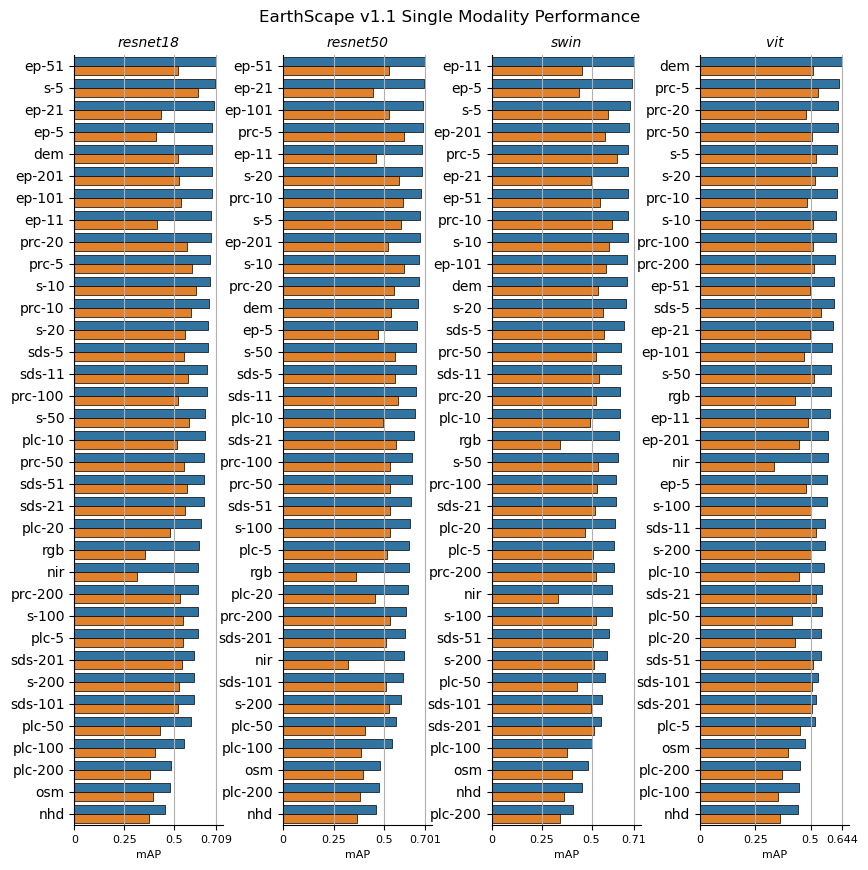

In [3]:
#############################################
# Modality Ranking Bar Charts
#############################################

# path to compiled data...
single_path = os.path.join(assets_dir, 'single_global.csv')
df_single = pd.read_csv(single_path)

# metric to plot...
metric = 'map'
metric_label = 'mAP'

# models to use...
models = ['resnet18', 'resnet50', 'swin', 'vit']

# output path for figure
output_path = os.path.join(assets_dir, 'rankings_single.png')


##### plot bar chart rankings...
fig, ax = plt.subplots(ncols=len(models), figsize=(2.5*len(models),10))
plt.subplots_adjust(wspace=0.4)
ax = ax.ravel()

idx = 0
for m in df_single['model'].unique():

    if m in [model.lower() for model in models]:

        df = df_single[df_single['model'] == m].copy()
        df.sort_values(f"macro_{metric} (id)", ascending=False, inplace=True)
        order = df['input'].to_list()
        max_val = df[f"macro_{metric} (id)"].max().item()
        df_plot = df.melt(id_vars=['input'], value_vars=[f"macro_{metric} (id)", f"macro_{metric} (cd)"], var_name='domain', value_name=metric)
        sns.barplot(ax=ax[idx], data=df_plot, x=metric, y='input', hue='domain', order=order, edgecolor='k', linewidth=0.5, legend=False)
        ax[idx].set_title(m, style='italic', fontsize=10)
        ax[idx].set_xticks([0, 0.25, 0.5, max_val])
        ax[idx].set_xticklabels(ax[idx].get_xticklabels(), fontsize=8)
        ax[idx].xaxis.set_major_formatter(FuncFormatter(lambda x, _: f"{x:.3f}".rstrip('0').rstrip('.')))
        idx += 1

for axes in ax:
    axes.set_xlabel(f"{metric_label}", fontsize=8)
    axes.set_ylabel('')
    axes.grid(visible=True, axis='x')
    axes.spines['right'].set_visible(False)
    axes.spines['top'].set_visible(False)

plt.suptitle(f"EarthScape v{VERSION} Single Modality Performance", y=0.925)

plt.savefig(output_path, dpi=500, bbox_inches='tight', pad_inches=0)
plt.show()

### Modality Rankings - All

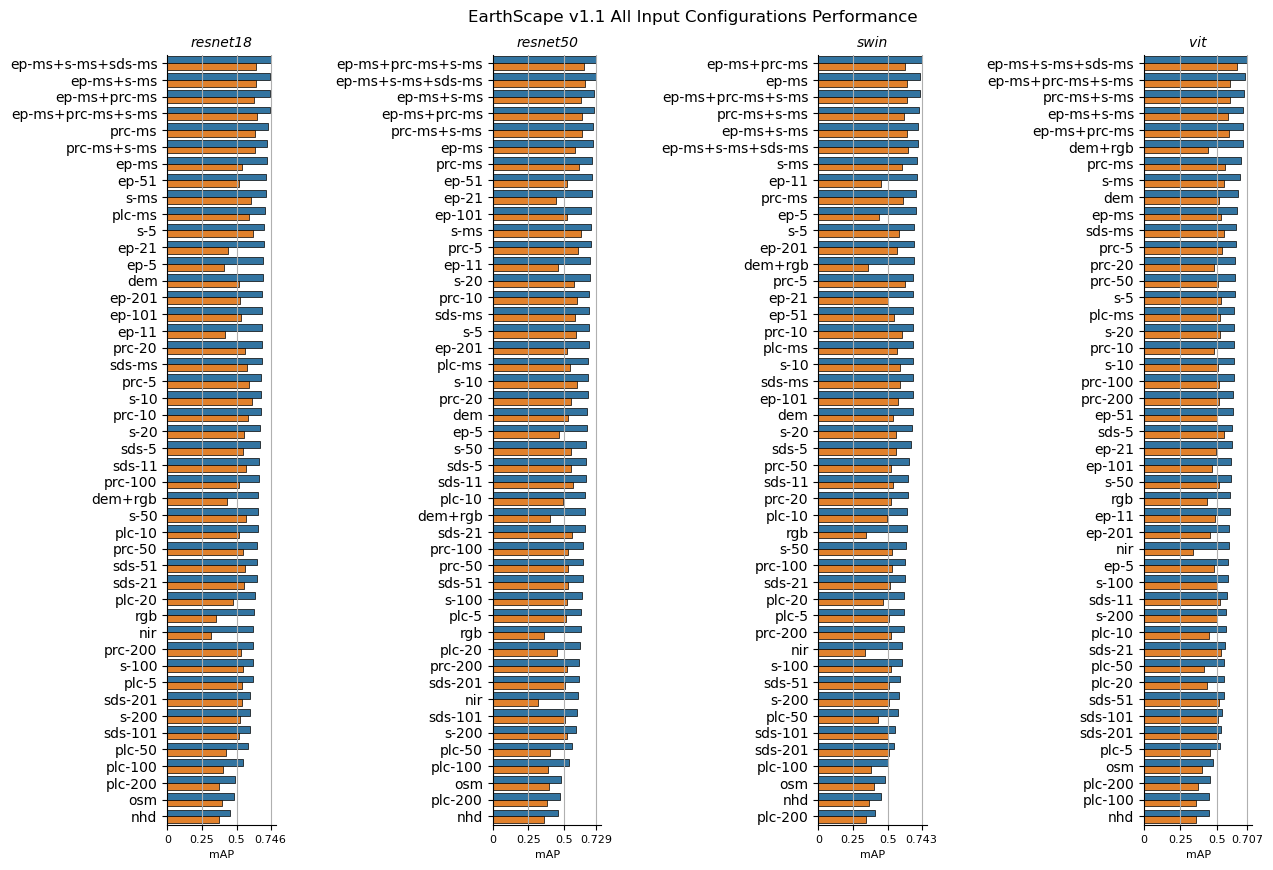

In [4]:
#############################################
# Modality Ranking Bar Charts
#############################################

# path to compiled data...
single_path = os.path.join(assets_dir, 'compiled_global.csv')
df_all = pd.read_csv(single_path)

# metric to plot...
metric = 'map'
metric_label = 'mAP'

# models to use...
models = ['resnet18', 'resnet50', 'swin', 'vit']

# output path for figure
output_path = os.path.join(assets_dir, 'rankings_all.png')


##### plot bar chart rankings...
fig, ax = plt.subplots(ncols=len(models), figsize=(3.5*len(models), 10))
plt.subplots_adjust(wspace=2)
ax = ax.ravel()

idx = 0
for m in df_all['model'].unique():

    if m in [model.lower() for model in models]:

        df = df_all[df_all['model'] == m].copy()
        df.sort_values(f"macro_{metric} (id)", ascending=False, inplace=True)
        order = df['input'].to_list()
        max_val = df[f"macro_{metric} (id)"].max().item()
        df_plot = df.melt(id_vars=['input'], value_vars=[f"macro_{metric} (id)", f"macro_{metric} (cd)"], var_name='domain', value_name=metric)
        sns.barplot(ax=ax[idx], data=df_plot, x=metric, y='input', hue='domain', order=order, edgecolor='k', linewidth=0.5, legend=False)
        ax[idx].set_title(m, style='italic', fontsize=10)
        ax[idx].set_xticks([0, 0.25, 0.5, max_val])
        ax[idx].set_xticklabels(ax[idx].get_xticklabels(), fontsize=8)
        ax[idx].xaxis.set_major_formatter(FuncFormatter(lambda x, _: f"{x:.3f}".rstrip('0').rstrip('.')))
        idx += 1

for axes in ax:
    axes.set_xlabel(f"{metric_label}", fontsize=8)
    axes.set_ylabel('')
    axes.grid(visible=True, axis='x')
    axes.spines['right'].set_visible(False)
    axes.spines['top'].set_visible(False)

plt.suptitle(f"EarthScape v{VERSION} All Input Configurations Performance", y=0.925)

plt.savefig(output_path, dpi=500, bbox_inches='tight', pad_inches=0)
plt.show()

### Scale Sensitivity

In [ ]:
# def parse_features(x):
#     """Function to parse modality/input strings into modality family and ground sampling distance (GSD) or multi-scale (MS) configurations."""
#     x_split = x.split('-')
#     if len(x_split) == 1:
#         return x_split[0], None
#     elif len(x_split) == 2:
#         return x_split[0], x_split[1]
#     else:
#         return 'multimodal', 'ms'
    

# def spatial_support(x, bins, raw_gsd=5):
#     """Function to group GSD features into families of effective area covered."""
#     if x is not None:
#         if str(x).isnumeric():
#             for bin in bins:
#                 if np.isclose(int(x) * raw_gsd, bin, atol=10):
#                     return bin
#         else:
#             return x
#     else:
#         return np.nan

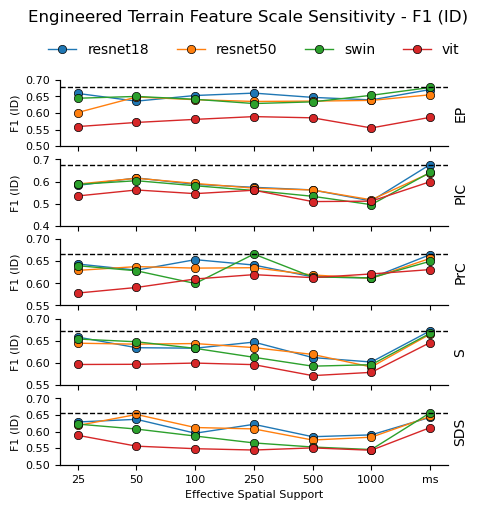

In [4]:
#############################################
# Terrain Feature Scale-Sensitivity - In-domain
#############################################

# path to compiled data...
compiled_path = os.path.join(assets_dir, 'compiled_global.csv')

# metric to plot...
metric = 'f1'
metric_label = 'F1'

# output path for figure
output_path = os.path.join(assets_dir, 'scale_sensitivity_map_id.png')


##### pre-processing...
# read compiled data into df
df_compiled = pd.read_csv(compiled_path)

# parse input modality string into modality family & scale (e.g., ep-51 -> ep, 51)
df_compiled[['family', 'scale']] = df_compiled['input'].apply(lambda x: pd.Series(parse_features(x)))

# define raw sensor feature family & scale (native GSD)...
engineered_features = ['ep', 'plc', 'prc', 's', 'sds']
mask1 = df_compiled['family'] == 'multimodal'
mask2 = df_compiled['family'].isin(engineered_features)
df_compiled.loc[~mask1 & ~mask2, ['family', 'scale']] = 'raw', '5'

# define spatial support (effective recteptive area)...
support_bins = [25, 50, 100, 250, 500, 1000]
support_order = support_bins + ['ms']
df_compiled['spatial_support'] = df_compiled['scale'].apply(lambda x: spatial_support(x, support_bins))
df_compiled['spatial_support'] = pd.Categorical(df_compiled['spatial_support'], categories=support_order, ordered=True)


##### plot...
fig, ax = plt.subplots(nrows=5, figsize=(5,5))
ax = ax.ravel()

# iterate through engineered terrain features...
for idx, fam in enumerate(engineered_features):

    # get terrain feature subset df
    subset = df_compiled[df_compiled['family'] == fam].copy()
    
    # iterate through model architectures & plot line with markers...
    for m in subset['model'].unique():
        df = subset[subset['model'] == m].copy()
        df.sort_values('spatial_support', ascending=True, na_position='last', inplace=True)
        df.reset_index(drop=True, inplace=True)
        df['spatial_support'] = df['spatial_support'].astype(str)
        ax[idx].plot(df['spatial_support'], df[f"macro_{metric} (id)"], marker='o', linewidth=1, markeredgecolor='k', markeredgewidth=0.5, label=m)

    max_val = subset[f"macro_{metric} (id)"].max()
    ax[idx].axhline(y=max_val, color='k', linewidth=1, linestyle='--')

    # customize plot...
    ylab = fam.upper() if not fam.startswith('p') else fam[:1].upper() + fam[1:2].lower() + fam[2:].upper()
    ax2 = ax[idx].twinx()
    ax2.set_yticks([])
    ax2.set_ylabel(ylab)
    ax[idx].set_ylabel(f"{metric_label} (ID)", fontsize=8)
    ax[idx].set_yticks(ax[idx].get_yticks())
    ax[idx].set_yticklabels(ax[idx].get_yticklabels(), fontsize=8)
    ax[idx].spines['right'].set_visible(False)
    ax[idx].spines['top'].set_visible(False)
    ax2.spines['right'].set_visible(False)
    ax2.spines['top'].set_visible(False)

# more plot customization...
ax[0].legend(loc='upper center', bbox_to_anchor=(0.5, 1.75), frameon=False, ncols=4)
ax[4].set_xticks(ax[4].get_xticks())
ax[4].set_xticklabels(ax[4].get_xticklabels(), fontsize=8)
ax[4].set_xlabel('Effective Spatial Support', fontsize=8)
for axes in ax[:-1]:
    axes.set_xticklabels('')
    axes.set_xlabel('')
fig.align_ylabels()
plt.suptitle(f"Engineered Terrain Feature Scale Sensitivity - {metric_label} (ID)", y=1.02)

# plot and save...
plt.savefig(output_path, bbox_inches='tight', pad_inches=0, dpi=300)
plt.show()

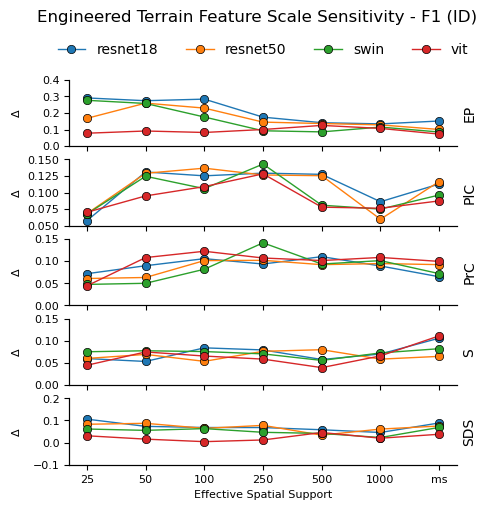

In [5]:
#############################################
# Terrain Feature Scale-Sensitivity - Delta
#############################################

# path to compiled data...
compiled_path = os.path.join(assets_dir, 'compiled_global.csv')

# metric to plot...
metric = 'f1'
metric_label = 'F1'

# output path for figure
output_path = os.path.join(assets_dir, 'scale_sensitivity_map_delta.png')


##### pre-processing...
# read compiled data into df
df_compiled = pd.read_csv(compiled_path)

# parse input modality string into modality family & scale (e.g., ep-51 -> ep, 51)
df_compiled[['family', 'scale']] = df_compiled['input'].apply(lambda x: pd.Series(parse_features(x)))

# define raw sensor feature family & scale (native GSD)...
engineered_features = ['ep', 'plc', 'prc', 's', 'sds']
mask1 = df_compiled['family'] == 'multimodal'
mask2 = df_compiled['family'].isin(engineered_features)
df_compiled.loc[~mask1 & ~mask2, ['family', 'scale']] = 'raw', '5'

# define spatial support (effective recteptive area)...
support_bins = [25, 50, 100, 250, 500, 1000]
support_order = support_bins + ['ms']
df_compiled['spatial_support'] = df_compiled['scale'].apply(lambda x: spatial_support(x, support_bins))
df_compiled['spatial_support'] = pd.Categorical(df_compiled['spatial_support'], categories=support_order, ordered=True)

df_compiled['delta'] = np.abs(df_compiled[f"macro_{metric} (id)"] - df_compiled[f"macro_{metric} (cd)"])


##### plot...
fig, ax = plt.subplots(nrows=5, figsize=(5,5))
ax = ax.ravel()

# iterate through engineered terrain features...
for idx, fam in enumerate(engineered_features):

    # get terrain feature subset df
    subset = df_compiled[df_compiled['family'] == fam].copy()
    
    # iterate through model architectures & plot line with markers...
    for m in subset['model'].unique():
        df = subset[subset['model'] == m].copy()
        df.sort_values('spatial_support', ascending=True, na_position='last', inplace=True)
        df.reset_index(drop=True, inplace=True)
        df['spatial_support'] = df['spatial_support'].astype(str)
        ax[idx].plot(df['spatial_support'], df['delta'], marker='o', linewidth=1, markeredgecolor='k', markeredgewidth=0.5, label=m)

    # max_val = subset[f"macro_{metric} (id)"].max()
    # ax[idx].axhline(y=max_val, color='k', linewidth=1, linestyle='--')

    # customize plot...
    ylab = fam.upper() if not fam.startswith('p') else fam[:1].upper() + fam[1:2].lower() + fam[2:].upper()
    ax2 = ax[idx].twinx()
    ax2.set_yticks([])
    ax2.set_ylabel(ylab)
    ax[idx].set_ylabel(r'$\Delta$', fontsize=8)
    ax[idx].set_yticks(ax[idx].get_yticks())
    ax[idx].set_yticklabels(ax[idx].get_yticklabels(), fontsize=8)
    ax[idx].spines['right'].set_visible(False)
    ax[idx].spines['top'].set_visible(False)
    ax2.spines['right'].set_visible(False)
    ax2.spines['top'].set_visible(False)

# more plot customization...
ax[0].legend(loc='upper center', bbox_to_anchor=(0.5, 1.75), frameon=False, ncols=4)
ax[4].set_xticks(ax[4].get_xticks())
ax[4].set_xticklabels(ax[4].get_xticklabels(), fontsize=8)
ax[4].set_xlabel('Effective Spatial Support', fontsize=8)
for axes in ax[:-1]:
    axes.set_xticklabels('')
    axes.set_xlabel('')
fig.align_ylabels()
plt.suptitle(f"Engineered Terrain Feature Scale Sensitivity - {metric_label} (ID)", y=1.02)

# plot and save...
plt.savefig(output_path, bbox_inches='tight', pad_inches=0, dpi=300)
plt.show()

### Cross-domain Robustness

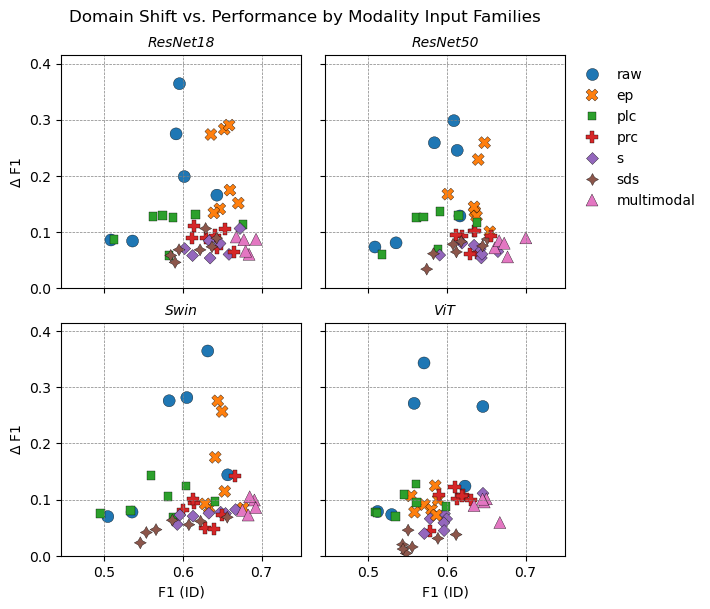

In [6]:
#############################################
# Cross-domain Performance - Delta Scatter plot
#############################################

# path to compiled data...
compiled_path = os.path.join(assets_dir, 'compiled_global.csv')

# metric to plot...
metric = 'f1'
metric_label = 'F1'

# define variables...
engineered_features = ['ep', 'plc', 'prc', 's', 'sds']
support_bins = [25, 50, 100, 250, 500, 1000]
support_order = support_bins + ['ms']
size_map = {k:v for k, v in zip(support_order, np.arange(10, 175, 25))}
family_order = ['raw', 'ep', 'plc', 'prc', 's', 'sds', 'multimodal']

# output path for figure
output_path = os.path.join(assets_dir, 'cross_performance_scatter_delta.png')


##### pre-processing...
# read compiled data into df
df_compiled = pd.read_csv(compiled_path)

# parse input modality string into modality family & scale (e.g., ep-51 -> ep, 51)
df_compiled[['family', 'scale']] = df_compiled['input'].apply(lambda x: pd.Series(parse_features(x)))

# define raw sensor feature family & scale (native GSD)...
mask1 = df_compiled['family'] == 'multimodal'
mask2 = df_compiled['family'].isin(engineered_features)
df_compiled.loc[~mask1 & ~mask2, ['family', 'scale']] = 'raw', '5'

# define spatial support (effective recteptive area)...
df_compiled['spatial_support'] = df_compiled['scale'].apply(lambda x: spatial_support(x, support_bins))
df_compiled['spatial_support'] = pd.Categorical(df_compiled['spatial_support'], categories=support_order, ordered=True)

# calculate cross-domain performance gap
df_compiled[f"delta {metric}"] = df_compiled[f"macro_{metric} (id)"] - df_compiled[f"macro_{metric} (cd)"]


#### plot delta scatter plot...
fig, ax = plt.subplots(nrows=2, ncols=2, sharex=True, sharey=True, figsize=(6.5,6.5))
fig.subplots_adjust(wspace=0.1, hspace=0.15)
ax = ax.ravel()

xmin = df_compiled[f"macro_{metric} (id)"].min() - 0.05
xmax = df_compiled[f"macro_{metric} (id)"].max() + 0.05
ymax = df_compiled[f"delta {metric}"].max() + 0.05

# iterate over model architectures...
models = df_compiled['model'].unique()
for idx, m in enumerate(models):

    # get subsets for specific architecture and multiscale...
    subset = df_compiled[df_compiled['model'] == m].copy()

    # plot scatterplot of each model architecture...
    legend = False
    if idx == 1:
        legend = True
    sns.scatterplot(ax=ax[idx], data=subset, x=f"macro_{metric} (id)", y=f"delta {metric}", hue='family', style='family', s=75, linewidth=0.25, edgecolor='k', legend=legend)

    # customize plot...
    ax[idx].set_xlim(xmin, xmax)
    ax[idx].set_ylim(0, ymax)
    ax[idx].set_xlabel(f"{metric_label} (ID)")
    ylab = r'$\Delta$ ' + f"{metric_label}"
    ax[idx].set_ylabel(ylab)
    if 'resnet' in m:
        name = 'ResNet' + m[-2:]
        ax[idx].set_title(name, style='italic', fontsize=10)
    elif 'vit' in m:
        ax[idx].set_title('ViT', style='italic', fontsize=10)
    elif 'swin' in m:
        ax[idx].set_title('Swin', style='italic', fontsize=10)
    ax[idx].grid(axis='both', linestyle='--', linewidth=0.5, color='0.5')
    
# legend
ax[1].legend(loc='upper left', bbox_to_anchor=(1,1), frameon=False)
plt.suptitle('Domain Shift vs. Performance by Modality Input Families', y=0.95)

# save and show...
plt.savefig(output_path, bbox_inches='tight', pad_inches=0, dpi=300)
plt.show()

### Performance vs. MMD

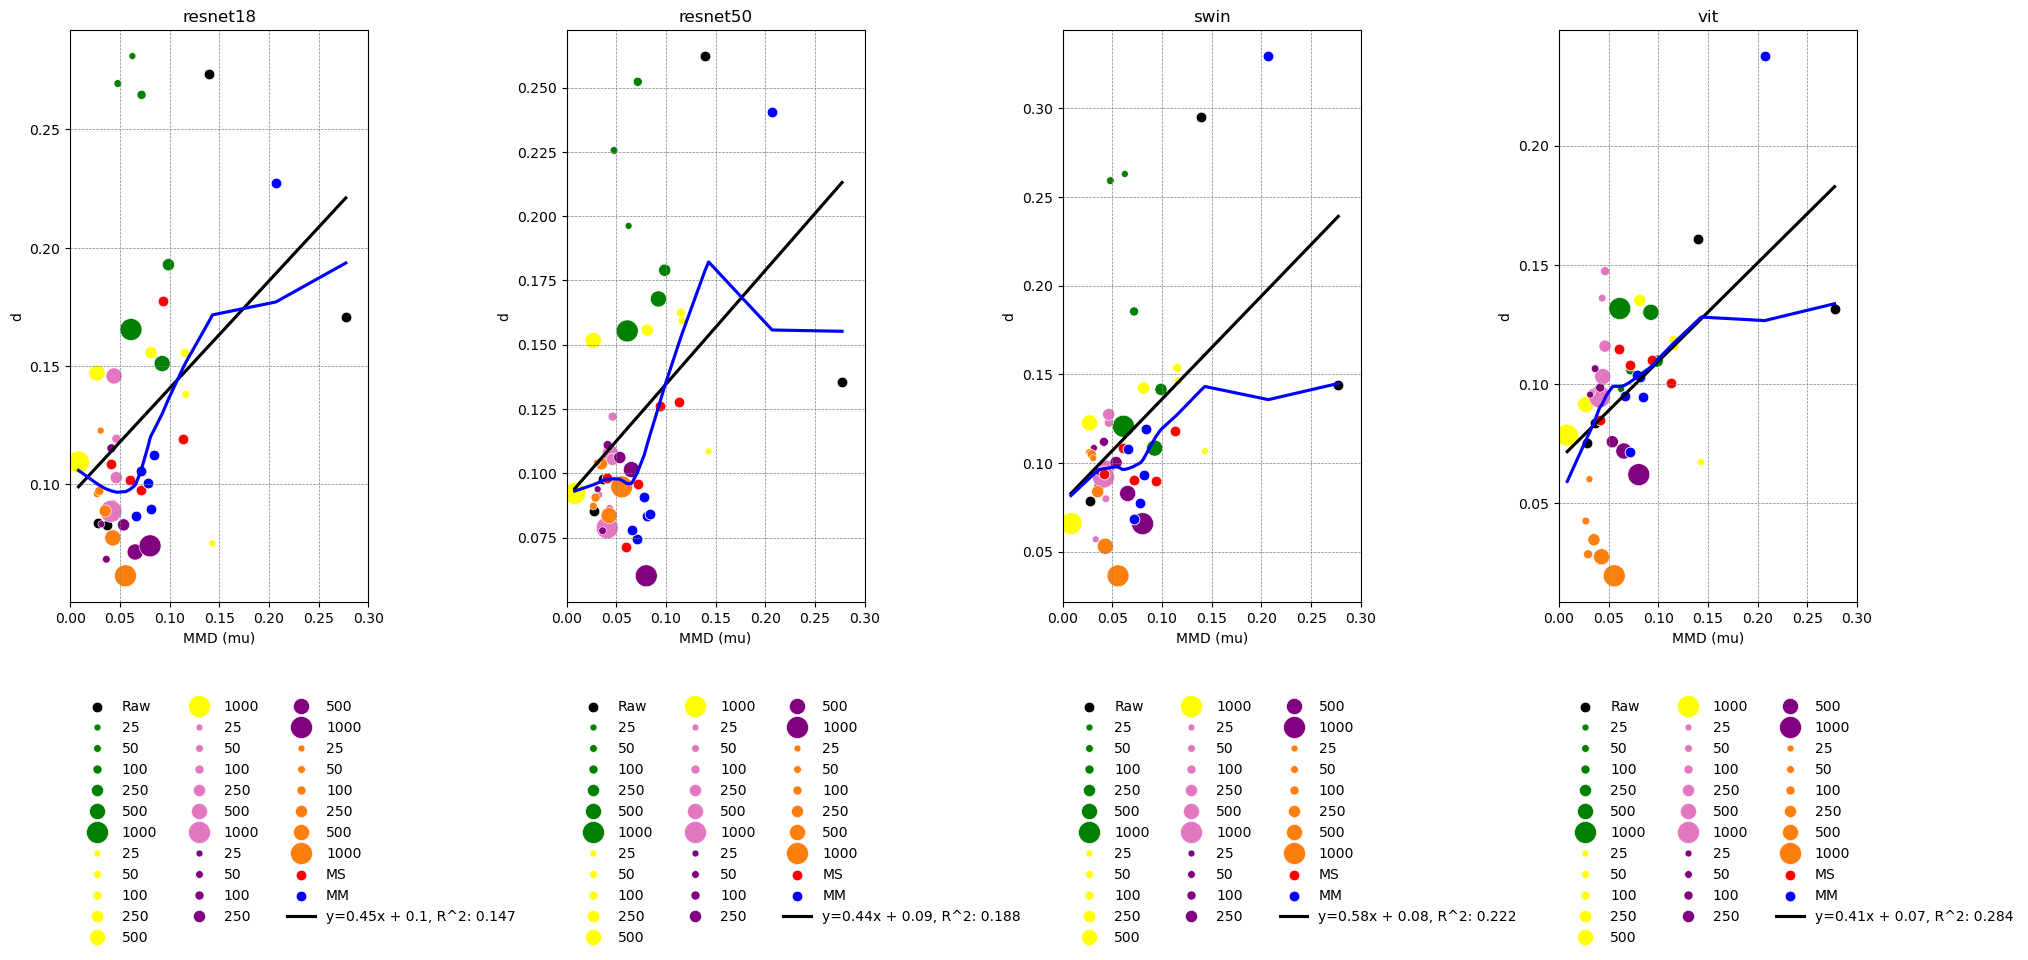

In [4]:
#############################################
# Performance vs. MMD
#############################################

# paths to compiled data...
compiled_path = os.path.join(assets_dir, 'compiled_global.csv')
mmd_path = glob.glob(r'../assets/data_eda/*mmd_summary.csv')[0]

# metric to plot...
metric = 'd'


# ##### pre-processing...
df_compiled = pd.read_csv(compiled_path)
df_compiled[["family", "spatial support"]] = df_compiled["input"].apply(parse_input_label)
df_mmd = pd.read_csv(mmd_path)
df_mmd['Feature'] = df_mmd['Feature'].apply(lambda x: str(x).lower().replace(' ', '-'))
df = pd.merge(left=df_compiled, right=df_mmd, left_on='input', right_on='Feature', how='inner')


##### calculate regression & plot...
fig, ax = plt.subplots(ncols=4, figsize=(20,10))

for idx, m in enumerate(df['model'].unique()):
    mask = df['model'] == m
    subset = df[mask].copy()

    subset['d'] = subset['macro_map (id)'] - subset['macro_map (cd)']
    subset['dr'] = (subset['macro_map (id)'] - subset['macro_map (cd)']) / subset['macro_map (id)'] * 100

    res = stats.linregress(subset["MMD (mu)"], subset[f"{metric}"])
    r2 = res.rvalue**2
    label = f"y={round(res.slope, 2)}x + {round(res.intercept, 2)}, R^2: {round(r2.item(), 3)}"

    sns.scatterplot(data=subset[subset['family'] == 'raw'], x='MMD (mu)', y=f"{metric}", ax=ax[idx], color='k', s=60, label='Raw')

    sns.scatterplot(data=subset[subset['family'] == 'ep'], x='MMD (mu)', y=f"{metric}", ax=ax[idx], color='green', size='spatial support', sizes=(25, 250))
    sns.scatterplot(data=subset[subset['family'] == 'plc'], x='MMD (mu)', y=f"{metric}", ax=ax[idx], color='yellow', size='spatial support', sizes=(25, 250))
    sns.scatterplot(data=subset[subset['family'] == 'prc'], x='MMD (mu)', y=f"{metric}", ax=ax[idx], color='tab:pink', size='spatial support', sizes=(25, 250))
    sns.scatterplot(data=subset[subset['family'] == 's'], x='MMD (mu)', y=f"{metric}", ax=ax[idx], color='purple', size='spatial support', sizes=(25, 250))
    sns.scatterplot(data=subset[subset['family'] == 'sds'], x='MMD (mu)', y=f"{metric}", ax=ax[idx], color='tab:orange', size='spatial support', sizes=(25, 250))

    sns.scatterplot(data=subset[subset['family'] == 'multi-scale'], x='MMD (mu)', y=f"{metric}", ax=ax[idx], color='red', s=60, label='MS')
    sns.scatterplot(data=subset[subset['family'] == 'multimodal'], x='MMD (mu)', y=f"{metric}", ax=ax[idx], color='blue', s=60, label='MM')

    x = sns.regplot(data=subset, x='MMD (mu)', y=f"{metric}", robust=False, ci=False, label=label, color='k', scatter=False, ax=ax[idx])
    sns.regplot(data=subset, x='MMD (mu)', y=f"{metric}", lowess=True, robust=False, ci=False, color='blue', scatter=False, ax=ax[idx])
    x.legend(loc='best', frameon=False, fontsize=8)

    sns.move_legend(x, loc='upper left', bbox_to_anchor=(0, -0.15), frameon=False, ncols=3)

    ax[idx].set_title(f"{m}")

    # ax[idx].set_ylim(0, 0.3)
    ax[idx].set_xlim(0, 0.3)

    ax[idx].grid(axis='both', linestyle='--', linewidth=0.5, color='0.5')


plt.tight_layout()

plt.savefig(f"{ASSETS_DIR}/baselines/classification/delta_vs_mmd_clf.svg")

plt.show()

# **Class-wise Performance**

## *Compile Single Modality Experiments*

In [49]:
##################################################
# Compile Class-wise Performance Metrics - Single
##################################################

# output path for global summary
output_path = os.path.join(assets_dir, 'single_class.csv')


##### compile global in- & cross-domain data...
# initialize df
df_class = pd.DataFrame(columns=['model', 'input'])

# collect global data from all experiments...
idx = 0
for d in single_dirs:
    
    # skip any files in root directory...
    if os.path.isfile(d):
        continue
    
    # metadata of model name & modality input...
    meta = os.path.basename(d)
    meta = meta.split('_')
    model_name = meta[0]
    modalities = meta[1]

    # in-domain...
    id_class_path = os.path.join(d, 'id_class.csv')
    id = pd.read_csv(id_class_path)
    id.columns = [col +' (id)' for col in id.columns]
    
    # cross-domain...
    cd_class_path = os.path.join(d, 'cd_class.csv')
    cd = pd.read_csv(cd_class_path)
    cd.columns = [col +' (cd)' for col in cd.columns]

    # merge datasets...
    df = pd.merge(left=id, right=cd, left_on='class (id)', right_on='class (cd)', how='left')
    df.rename(columns={'class (id)': 'class', 'decision threshold (id)':'decision threshold'}, inplace=True)
    df.drop(columns=['decision threshold (cd)', 'class (cd)', 'specificity (id)', 'specificity (cd)'], inplace=True)

    df_class = pd.concat([df_class, df], ignore_index=True, axis=0)
    df_class.loc[idx:idx+len(df), 'model'] = model_name
    df_class.loc[idx:idx+len(df), 'input'] = modalities
    df_class.loc[idx:idx+len(df), df_class.columns[2:]] = df.values

    idx += len(df)

# save & display...
df_class.sort_values(['model', 'input'], inplace=True)
df_class.reset_index(drop=True, inplace=True)
int_cols = ['ground truth (id)', 'predicted (id)', 'ground truth (cd)', 'predicted (cd)']
df_class[int_cols] = df_class[int_cols].astype(int)
df_class.to_csv(output_path, index=False)
df_class.head(14)

,model,input,class,decision threshold,ground truth (id),predicted (id),precision (id),recall (id),f1 (id),auroc (id),ap (id),accuracy (id),ground truth (cd),predicted (cd),precision (cd),recall (cd),f1 (cd),auroc (cd),ap (cd),accuracy (cd)
0,resnet18,dem,af1,0.402417,571,538,0.622677,0.586690,0.604148,0.757856,0.703485,0.714193,435,567,0.291005,0.379310,0.329341,0.555249,0.341223,0.562500
1,resnet18,dem,Qal,0.335367,950,1010,0.776238,0.825263,0.800000,0.824415,0.895711,0.744792,845,1331,0.547708,0.862722,0.670037,0.484279,0.578969,0.532552
2,resnet18,dem,Qaf,0.058684,13,28,0.107143,0.230769,0.146341,0.880954,0.087856,0.977214,6,0,0.000000,0.000000,0.000000,0.685403,0.032778,0.996094
3,resnet18,dem,Qat,0.084915,61,210,0.228571,0.786885,0.354244,0.907730,0.308434,0.886068,77,2,0.000000,0.000000,0.000000,0.806103,0.162131,0.948568
4,resnet18,dem,Qc,0.378547,749,805,0.855901,0.919893,0.886744,0.962340,0.966037,0.885417,456,763,0.579292,0.969298,0.725185,0.945362,0.882790,0.781901
5,resnet18,dem,Qca,0.271758,432,514,0.686770,0.817130,0.746300,0.929933,0.864910,0.843750,249,242,0.636364,0.618474,0.627291,0.888371,0.634261,0.880859
6,resnet18,dem,Qr,0.387985,1433,1497,0.943220,0.985345,0.963823,0.930318,0.994803,0.930990,1511,1536,0.983724,1.000000,0.991795,0.803058,0.993830,0.983724
7,resnet18,ep-101,af1,0.142561,571,692,0.650289,0.788091,0.712589,0.841750,0.795029,0.763672,435,401,0.618454,0.570115,0.593301,0.784572,0.672870,0.778646
8,resnet18,ep-101,Qal,0.335206,950,1121,0.740410,0.873684,0.801545,0.809657,0.881219,0.732422,845,1304,0.587423,0.906509,0.712890,0.758936,0.818864,0.598307
9,resnet18,ep-101,Qaf,0.157042,13,32,0.093750,0.230769,0.133333,0.853376,0.085173,0.974609,6,7,0.000000,0.000000,0.000000,0.732244,0.010172,0.991536


## *Compile Multi-scale Experiments*

In [52]:
##################################################
# Compile Class-wise Performance Metrics - Multiscale
##################################################

# output path for global summary
output_path = os.path.join(assets_dir, 'multiscale_class.csv')


##### compile global in- & cross-domain data...
# initialize df
df_class = pd.DataFrame(columns=['model', 'input'])

# collect global data from all experiments...
idx = 0
for d in ms_dirs:
    
    # skip any files in root directory...
    if os.path.isfile(d):
        continue
    
    # metadata of model name & modality input...
    meta = os.path.basename(d)
    meta = meta.split('_')
    model_name = meta[0]
    modalities = meta[1]

    # in-domain...
    id_class_path = os.path.join(d, 'id_class.csv')
    id = pd.read_csv(id_class_path)
    id.columns = [col +' (id)' for col in id.columns]
    
    # cross-domain...
    cd_class_path = os.path.join(d, 'cd_class.csv')
    cd = pd.read_csv(cd_class_path)
    cd.columns = [col +' (cd)' for col in cd.columns]

    # merge datasets...
    df = pd.merge(left=id, right=cd, left_on='class (id)', right_on='class (cd)', how='left')
    df.rename(columns={'class (id)': 'class', 'decision threshold (id)':'decision threshold'}, inplace=True)
    df.drop(columns=['decision threshold (cd)', 'class (cd)', 'specificity (id)', 'specificity (cd)'], inplace=True)

    df_class = pd.concat([df_class, df], ignore_index=True, axis=0)
    df_class.loc[idx:idx+len(df), 'model'] = model_name
    df_class.loc[idx:idx+len(df), 'input'] = modalities
    df_class.loc[idx:idx+len(df), df_class.columns[2:]] = df.values

    idx += len(df)

# save & display...
df_class.sort_values(['model', 'input'], inplace=True)
df_class.reset_index(drop=True, inplace=True)
int_cols = ['ground truth (id)', 'predicted (id)', 'ground truth (cd)', 'predicted (cd)']
df_class[int_cols] = df_class[int_cols].astype(int)
df_class.to_csv(output_path, index=False)
df_class.head(14)

,model,input,class,decision threshold,ground truth (id),predicted (id),precision (id),recall (id),f1 (id),auroc (id),ap (id),accuracy (id),ground truth (cd),predicted (cd),precision (cd),recall (cd),f1 (cd),auroc (cd),ap (cd),accuracy (cd)
0,resnet18,ep-ms,af1,0.166701,571,641,0.678627,0.761821,0.717822,0.852539,0.807584,0.777344,435,363,0.691460,0.577011,0.629073,0.799860,0.697051,0.807292
1,resnet18,ep-ms,Qal,0.560404,950,918,0.823529,0.795789,0.809422,0.844297,0.903840,0.768229,845,1058,0.663516,0.830769,0.737782,0.742563,0.781220,0.675130
2,resnet18,ep-ms,Qaf,0.061369,13,63,0.047619,0.230769,0.078947,0.889388,0.126165,0.954427,6,17,0.058824,0.166667,0.086957,0.752288,0.021241,0.986328
3,resnet18,ep-ms,Qat,0.441588,61,72,0.430556,0.508197,0.466165,0.910308,0.396106,0.953776,77,201,0.218905,0.571429,0.316547,0.864148,0.293067,0.876302
4,resnet18,ep-ms,Qc,0.464265,749,790,0.853165,0.899866,0.875893,0.957726,0.960449,0.875651,456,281,0.629893,0.388158,0.480326,0.744528,0.587996,0.750651
5,resnet18,ep-ms,Qca,0.457633,432,466,0.744635,0.803241,0.772829,0.933273,0.849968,0.867188,249,189,0.455026,0.345382,0.392694,0.796463,0.421057,0.826823
6,resnet18,ep-ms,Qr,0.447874,1433,1448,0.966160,0.976274,0.971191,0.939044,0.995225,0.945964,1511,1532,0.983681,0.997353,0.990470,0.813488,0.994926,0.981120
7,resnet18,plc-ms,af1,0.283573,571,620,0.651613,0.707531,0.678421,0.813658,0.758062,0.750651,435,590,0.474576,0.643678,0.546341,0.751695,0.591472,0.697266
8,resnet18,plc-ms,Qal,0.419322,950,1118,0.729875,0.858947,0.789168,0.802948,0.879762,0.716146,845,1371,0.572575,0.928994,0.708484,0.763288,0.828843,0.579427
9,resnet18,plc-ms,Qaf,0.049073,13,22,0.272727,0.461538,0.342857,0.913531,0.232252,0.985026,6,8,0.125000,0.166667,0.142857,0.840414,0.041318,0.992188


## *Compile Multimodal Experiments*

In [57]:
##################################################
# Compile Class-wise Performance Metrics - Multimodal
##################################################

# output path for global summary
output_path = os.path.join(assets_dir, 'multimodal_class.csv')


##### compile global in- & cross-domain data...
# initialize df
df_class = pd.DataFrame(columns=['model', 'input'])

# collect global data from all experiments...
idx = 0
for d in mm_dirs:
    
    # skip any files in root directory...
    if os.path.isfile(d):
        continue
    
    # metadata of model name & modality input...
    meta = os.path.basename(d)
    meta = meta.split('_')
    model_name = meta[0]
    modalities = meta[1]

    # in-domain...
    id_class_path = os.path.join(d, 'id_class.csv')
    id = pd.read_csv(id_class_path)
    id.columns = [col +' (id)' for col in id.columns]
    
    # cross-domain...
    cd_class_path = os.path.join(d, 'cd_class.csv')
    cd = pd.read_csv(cd_class_path)
    cd.columns = [col +' (cd)' for col in cd.columns]

    # merge datasets...
    df = pd.merge(left=id, right=cd, left_on='class (id)', right_on='class (cd)', how='left')
    df.rename(columns={'class (id)': 'class', 'decision threshold (id)':'decision threshold'}, inplace=True)
    df.drop(columns=['decision threshold (cd)', 'class (cd)', 'specificity (id)', 'specificity (cd)'], inplace=True)

    df_class = pd.concat([df_class, df], ignore_index=True, axis=0)
    df_class.loc[idx:idx+len(df), 'model'] = model_name
    df_class.loc[idx:idx+len(df), 'input'] = modalities
    df_class.loc[idx:idx+len(df), df_class.columns[2:]] = df.values

    idx += len(df)

# save & display...
df_class.sort_values(['model', 'input'], inplace=True)
df_class.reset_index(drop=True, inplace=True)
int_cols = ['ground truth (id)', 'predicted (id)', 'ground truth (cd)', 'predicted (cd)']
df_class[int_cols] = df_class[int_cols].astype(int)
df_class.to_csv(output_path, index=False)
df_class.head(14)

,model,input,class,decision threshold,ground truth (id),predicted (id),precision (id),recall (id),f1 (id),auroc (id),ap (id),accuracy (id),ground truth (cd),predicted (cd),precision (cd),recall (cd),f1 (cd),auroc (cd),ap (cd),accuracy (cd)
0,resnet18,dem+rgb,af1,0.364054,571,515,0.722330,0.651489,0.685083,0.837819,0.792015,0.777344,435,979,0.295199,0.664368,0.408769,0.540670,0.329301,0.455729
1,resnet18,dem+rgb,Qal,0.433651,950,1123,0.729297,0.862105,0.790159,0.764169,0.841296,0.716797,845,401,0.586035,0.278107,0.377207,0.524012,0.552495,0.494792
2,resnet18,dem+rgb,Qaf,0.083251,13,59,0.050847,0.230769,0.083333,0.869539,0.067017,0.957031,6,0,0.000000,0.000000,0.000000,0.338671,0.003252,0.996094
3,resnet18,dem+rgb,Qat,0.454679,61,35,0.257143,0.147541,0.187500,0.877455,0.227220,0.949219,77,0,0.000000,0.000000,0.000000,0.677728,0.117256,0.949870
4,resnet18,dem+rgb,Qc,0.633571,749,701,0.841655,0.787717,0.813793,0.907991,0.914234,0.824219,456,724,0.466851,0.741228,0.572881,0.745005,0.523184,0.671875
5,resnet18,dem+rgb,Qca,0.347368,432,528,0.626894,0.766204,0.689583,0.875895,0.757775,0.805990,249,231,0.497835,0.461847,0.479167,0.848229,0.482231,0.837240
6,resnet18,dem+rgb,Qr,0.513883,1433,1482,0.946019,0.978367,0.961921,0.913082,0.993188,0.927734,1511,1507,0.984738,0.982131,0.983433,0.802356,0.994417,0.967448
7,resnet18,ep-ms+prc-ms,af1,0.349133,571,602,0.696013,0.733800,0.714408,0.853848,0.818048,0.781901,435,578,0.591696,0.786207,0.675222,0.859626,0.766670,0.785807
8,resnet18,ep-ms+prc-ms,Qal,0.423948,950,1019,0.791953,0.849474,0.819705,0.859071,0.916985,0.768880,845,1188,0.641414,0.901775,0.749631,0.735158,0.766196,0.668620
9,resnet18,ep-ms+prc-ms,Qaf,0.285537,13,19,0.157895,0.230769,0.187500,0.911662,0.179601,0.983073,6,9,0.000000,0.000000,0.000000,0.708824,0.010989,0.990234


## *Compile All Data*

In [60]:
##################################################
# Compile All Class-wise Experiments
##################################################

# paths to single, multi-scale, & multimodal compilations...
single_path = os.path.join(assets_dir, "single_class.csv")
ms_path = os.path.join(assets_dir, "multiscale_class.csv")
mm_path = os.path.join(assets_dir, "multimodal_class.csv")

# output path
output_path = os.path.join(assets_dir, 'compiled_class.csv')


##### compile data...
df_list = []
df_list.append(pd.read_csv(single_path))
df_list.append(pd.read_csv(ms_path))
df_list.append(pd.read_csv(mm_path))

df = pd.concat(df_list)
df.reset_index(drop=True, inplace=True)

df.to_csv(output_path, index=False)
df.head(14)

,model,input,class,decision threshold,ground truth (id),predicted (id),precision (id),recall (id),f1 (id),auroc (id),ap (id),accuracy (id),ground truth (cd),predicted (cd),precision (cd),recall (cd),f1 (cd),auroc (cd),ap (cd),accuracy (cd)
0,resnet18,dem,af1,0.402417,571,538,0.622677,0.586690,0.604148,0.757856,0.703485,0.714193,435,567,0.291005,0.379310,0.329341,0.555249,0.341223,0.562500
1,resnet18,dem,Qal,0.335367,950,1010,0.776238,0.825263,0.800000,0.824415,0.895711,0.744792,845,1331,0.547708,0.862722,0.670037,0.484279,0.578969,0.532552
2,resnet18,dem,Qaf,0.058684,13,28,0.107143,0.230769,0.146341,0.880954,0.087856,0.977214,6,0,0.000000,0.000000,0.000000,0.685403,0.032778,0.996094
3,resnet18,dem,Qat,0.084915,61,210,0.228571,0.786885,0.354244,0.907730,0.308434,0.886068,77,2,0.000000,0.000000,0.000000,0.806103,0.162131,0.948568
4,resnet18,dem,Qc,0.378547,749,805,0.855901,0.919893,0.886744,0.962340,0.966037,0.885417,456,763,0.579292,0.969298,0.725185,0.945362,0.882790,0.781901
5,resnet18,dem,Qca,0.271758,432,514,0.686770,0.817130,0.746300,0.929933,0.864910,0.843750,249,242,0.636364,0.618474,0.627291,0.888371,0.634261,0.880859
6,resnet18,dem,Qr,0.387985,1433,1497,0.943220,0.985345,0.963823,0.930318,0.994803,0.930990,1511,1536,0.983724,1.000000,0.991795,0.803058,0.993830,0.983724
7,resnet18,ep-101,af1,0.142561,571,692,0.650289,0.788091,0.712589,0.841750,0.795029,0.763672,435,401,0.618454,0.570115,0.593301,0.784572,0.672870,0.778646
8,resnet18,ep-101,Qal,0.335206,950,1121,0.740410,0.873684,0.801545,0.809657,0.881219,0.732422,845,1304,0.587423,0.906509,0.712890,0.758936,0.818864,0.598307
9,resnet18,ep-101,Qaf,0.157042,13,32,0.093750,0.230769,0.133333,0.853376,0.085173,0.974609,6,7,0.000000,0.000000,0.000000,0.732244,0.010172,0.991536


## *Compile Sample Predictions*

## *Visualizations*

### Performance vs. Class-area Proportion

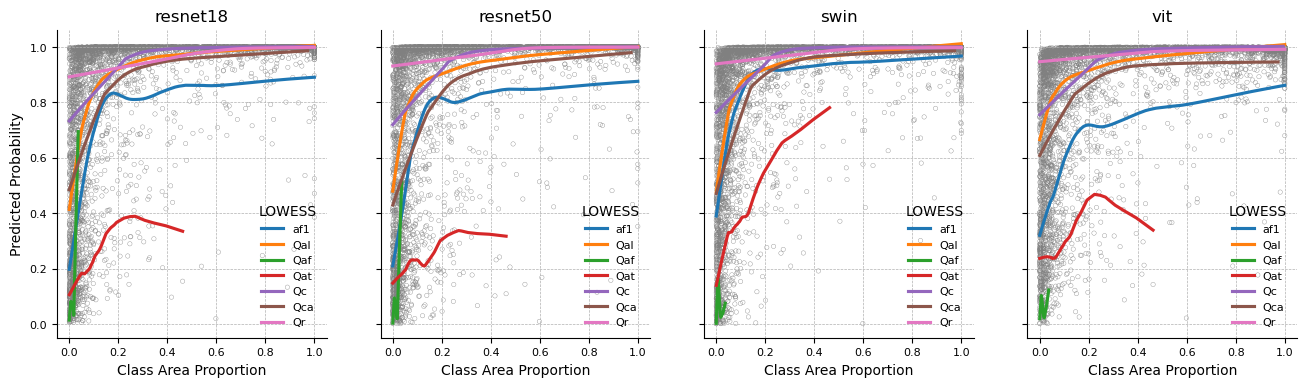

In [3]:
#############################################
# Model Prediction vs. Exposed Class Area
#############################################

# modality configuration
exp = 'ep-ms+prc-ms+s-ms'
# exp = 'ep-51'

# relevant experiment directories (modality config fun in all models)
exp_dirs = glob.glob(f"../experiments/baselines/classification/**/*{exp}*")

# model predictions of in-domain test set
pred_paths = [os.path.join(d, 'predictions_id.csv') for d in exp_dirs]
pred_paths = [d for d in pred_paths if 'variance' not in d]

# class area proportions path
areas_path = glob.glob(r'../data/*areas.csv')[0]

# ouput path
output_path = os.path.join(assets_dir, 'prob_vs_area.png')


##### plot...
# read areas dataframe 
areas = pd.read_csv(areas_path)

spatial_corr = {}
imbalance_corr = {}

# set up figure...one subplot for each model
fig, ax = plt.subplots(ncols=4, sharey=True, figsize=(16,4))

# iterate through each model experiment...
for idx, path in enumerate(pred_paths):

    model = os.path.dirname(path)
    model = os.path.basename(model).split('_')[0]

    spatial_corr[model] = {'class': [], 'rsq': [], 'pcc': [], 'srcc': [], 'krcc': []}

    preds = pd.read_csv(path)                                                           # read predictions into dataframe
    df = preds.merge(right=areas, how='left', on='patch_id', suffixes=['', '_area'])    # merge with area proportions
    df.set_index('patch_id', drop=True, inplace=True)                                   # reset index using patch_id

    # define class probability & class area proportions columns...
    area_cols = [col for col in df.columns if 'area' in col]
    prob_cols = [col.split('_')[0] for col in area_cols]

    # iterate through each class...
    for a, p in zip(area_cols, prob_cols):

        df2 = df[[a, p]].copy()                                              # subset dataframe for class of interest
        df2 = df2[df2[a] > 0]                                                # only process patches with class presence

        spatial_corr[model]['class'].append(p)
        spatial_corr[model]['rsq'].append(round(df2[p].corr(df2[a], method='pearson').item()**2, 3))
        spatial_corr[model]['pcc'].append(round(df2[p].corr(df2[a], method='pearson').item(), 3))
        spatial_corr[model]['srcc'].append(round(df2[p].corr(df2[a], method='spearman').item(), 3))
        spatial_corr[model]['krcc'].append(round(df2[p].corr(df2[a], method='kendall').item(), 3))

        # print(len(df2))

        # plot lowess curve...
        sns.regplot(ax=ax[idx], data=df2, x=a, y=p, lowess=True, scatter=False, label=p)
        sns.scatterplot(ax=ax[idx], data=df2, x=a, y=p, edgecolor='0.5', s=10, facecolor='none')

    # customize plot...
    ax[idx].legend(loc='lower right', bbox_to_anchor=(1, 0), frameon=False, fontsize=8, title='LOWESS')
    ax[idx].set_title(model)
    ticks = np.arange(0, 1.01, 0.2)
    ax[idx].set_xlabel('Class Area Proportion')
    ax[idx].set_xticks(ticks)
    ax[idx].set_xticklabels(ax[idx].get_xticklabels(), fontsize=8)
    ax[idx].set_yticks(ticks)
    ax[idx].set_yticklabels([])
    ax[idx].set_ylabel('')
    ax[idx].grid(axis='both', linewidth=0.5, linestyle='--')
    ax[idx].spines['right'].set_visible(False)
    ax[idx].spines['top'].set_visible(False)

# set y axis for first plot...
ax[0].set_ylabel('Predicted Probability')
ax[0].set_yticks(ticks)
ax[0].set_yticklabels([str(round(s, 1)) for s in ticks], fontsize=8)

# save and show...
# plt.savefig(output_path, bbox_inches='tight', pad_inches=0, dpi=300)
# plt.savefig(r'../assets/baselines/classification/prob_vs_area.svg')
plt.show()

In [ ]:
spatial_corr

{'resnet18': {'class': ['af1', 'Qal', 'Qaf', 'Qat', 'Qc', 'Qca', 'Qr'],
  'rsq': [0.205, 0.191, 0.037, 0.154, 0.248, 0.231, 0.197],
  'pcc': [0.453, 0.437, 0.192, 0.392, 0.498, 0.48, 0.444],
  'srcc': [0.63, 0.668, 0.382, 0.443, 0.805, 0.623, 0.542],
  'krcc': [0.439, 0.482, 0.245, 0.292, 0.594, 0.437, 0.374]},
 'resnet50': {'class': ['af1', 'Qal', 'Qaf', 'Qat', 'Qc', 'Qca', 'Qr'],
  'rsq': [0.21, 0.12, 0.175, 0.035, 0.276, 0.2, 0.159],
  'pcc': [0.458, 0.346, 0.418, 0.188, 0.526, 0.447, 0.399],
  'srcc': [0.627, 0.582, 0.371, 0.231, 0.745, 0.594, 0.386],
  'krcc': [0.433, 0.415, 0.219, 0.145, 0.535, 0.413, 0.258]},
 'swin': {'class': ['af1', 'Qal', 'Qaf', 'Qat', 'Qc', 'Qca', 'Qr'],
  'rsq': [0.21, 0.167, 0.02, 0.27, 0.225, 0.228, 0.133],
  'pcc': [0.459, 0.409, -0.14, 0.52, 0.474, 0.478, 0.364],
  'srcc': [0.677, 0.657, -0.058, 0.484, 0.914, 0.682, 0.457],
  'krcc': [0.477, 0.475, -0.065, 0.334, 0.732, 0.49, 0.316]},
 'vit': {'class': ['af1', 'Qal', 'Qaf', 'Qat', 'Qc', 'Qca', 'Qr'],
 

In [ ]:
macro_avg = {model: {metric: round(np.mean(values).item(), 3) for metric, values in metrics.items() if metric != "class"} for model, metrics in spatial_corr.items()}

macro_avg

{'resnet18': {'rsq': 0.18, 'pcc': 0.414, 'srcc': 0.585, 'krcc': 0.409},
 'resnet50': {'rsq': 0.168, 'pcc': 0.397, 'srcc': 0.505, 'krcc': 0.345},
 'swin': {'rsq': 0.179, 'pcc': 0.366, 'srcc': 0.545, 'krcc': 0.394},
 'vit': {'rsq': 0.149, 'pcc': 0.332, 'srcc': 0.473, 'krcc': 0.336}}

In [54]:

# modality configuration
exp = 'ep-ms+prc-ms+s-ms'


class_path = r'../assets/baselines/classification/compiled_class.csv'

df_class = pd.read_csv(class_path)

df_class = df_class[df_class['input'] == exp]

df_class.head()

,model,input,class,decision threshold,ground truth (id),predicted (id),precision (id),recall (id),f1 (id),auroc (id),ap (id),accuracy (id),ground truth (cd),predicted (cd),precision (cd),recall (cd),f1 (cd),auroc (cd),ap (cd),accuracy (cd)
1134,resnet18,ep-ms+prc-ms+s-ms,af1,0.168711,571,670,0.670149,0.786340,0.723610,0.848431,0.807903,0.776693,435,644,0.546584,0.809195,0.652456,0.848372,0.756994,0.755859
1135,resnet18,ep-ms+prc-ms+s-ms,Qal,0.221138,950,1110,0.765766,0.894737,0.825243,0.869114,0.921910,0.765625,845,1255,0.640637,0.951479,0.765714,0.803449,0.843116,0.679688
1136,resnet18,ep-ms+prc-ms+s-ms,Qaf,0.334072,13,29,0.103448,0.230769,0.142857,0.897015,0.135275,0.976562,6,12,0.000000,0.000000,0.000000,0.701743,0.009630,0.988281
1137,resnet18,ep-ms+prc-ms+s-ms,Qat,0.208806,61,67,0.432836,0.475410,0.453125,0.936271,0.404273,0.954427,77,147,0.197279,0.376623,0.258929,0.768245,0.153386,0.891927
1138,resnet18,ep-ms+prc-ms+s-ms,Qc,0.514772,749,730,0.930137,0.906542,0.918188,0.976680,0.978682,0.921224,456,520,0.807692,0.921053,0.860656,0.977532,0.955885,0.911458


In [55]:

imbalance_path = r'../assets/data_eda/esv1p1_imbalance_metrics.csv'

df_imbalance = pd.read_csv(imbalance_path)

df_imbalance.head()

,class,Frequency (n),Frequency (%),IRLbl,N_eff,Mean Area,SD Area,Dominant Rate
0,Qr,29271,94.367786,1.000000,9464.557233,0.650765,0.358058,0.701496
1,Qal,18802,60.616416,1.556802,8474.547516,0.089023,0.167953,0.058385
2,Qc,13768,44.387130,2.126017,7476.324808,0.141715,0.242290,0.148075
3,af1,10908,35.166677,2.683443,6640.706952,0.050993,0.160891,0.034625
4,Qca,7666,24.714682,3.818289,5354.278166,0.060953,0.154080,0.053679


In [57]:

df = pd.merge(left=df_class, right=df_imbalance, how='left', on='class')

df.head()

,model,input,class,decision threshold,ground truth (id),predicted (id),precision (id),recall (id),f1 (id),auroc (id),...,auroc (cd),ap (cd),accuracy (cd),Frequency (n),Frequency (%),IRLbl,N_eff,Mean Area,SD Area,Dominant Rate
0,resnet18,ep-ms+prc-ms+s-ms,af1,0.168711,571,670,0.670149,0.786340,0.723610,0.848431,...,0.848372,0.756994,0.755859,10908,35.166677,2.683443,6640.706952,0.050993,0.160891,0.034625
1,resnet18,ep-ms+prc-ms+s-ms,Qal,0.221138,950,1110,0.765766,0.894737,0.825243,0.869114,...,0.803449,0.843116,0.679688,18802,60.616416,1.556802,8474.547516,0.089023,0.167953,0.058385
2,resnet18,ep-ms+prc-ms+s-ms,Qaf,0.334072,13,29,0.103448,0.230769,0.142857,0.897015,...,0.701743,0.009630,0.988281,270,0.870462,108.411111,266.400726,0.000168,0.002835,0.000000
3,resnet18,ep-ms+prc-ms+s-ms,Qat,0.208806,61,67,0.432836,0.475410,0.453125,0.936271,...,0.768245,0.153386,0.891927,1435,4.626346,20.397909,1336.854161,0.006383,0.045366,0.003740
4,resnet18,ep-ms+prc-ms+s-ms,Qc,0.514772,749,730,0.930137,0.906542,0.918188,0.976680,...,0.977532,0.955885,0.911458,13768,44.387130,2.126017,7476.324808,0.141715,0.242290,0.148075


In [66]:

imbalance_corr = {}

for m in df['model'].unique():

    imbalance_corr[m] = {}
    subset = df[df['model'] == m].copy()

    imbalance_corr[m]['r_squared'] = subset['f1 (id)'].corr(subset['Frequency (n)'], method='pearson')**2
    imbalance_corr[m]['pcc'] = subset['f1 (id)'].corr(subset['Frequency (n)'], method='pearson')
    imbalance_corr[m]['srcc'] = subset['f1 (id)'].corr(subset['Frequency (n)'], method='spearman')
    imbalance_corr[m]['krcc'] = subset['f1 (id)'].corr(subset['Frequency (n)'], method='kendall')


In [67]:
macro_avg = {model: {metric: round(np.mean(values).item(), 3) for metric, values in metrics.items() if metric != "class"} for model, metrics in imbalance_corr.items()}

macro_avg

{'resnet18': {'r_squared': 0.659, 'pcc': 0.812, 'srcc': 0.929, 'krcc': 0.81},
 'resnet50': {'r_squared': 0.688, 'pcc': 0.829, 'srcc': 0.821, 'krcc': 0.714},
 'swin': {'r_squared': 0.677, 'pcc': 0.823, 'srcc': 0.929, 'krcc': 0.81},
 'vit': {'r_squared': 0.663, 'pcc': 0.814, 'srcc': 0.821, 'krcc': 0.714}}

### Performance Heatmap

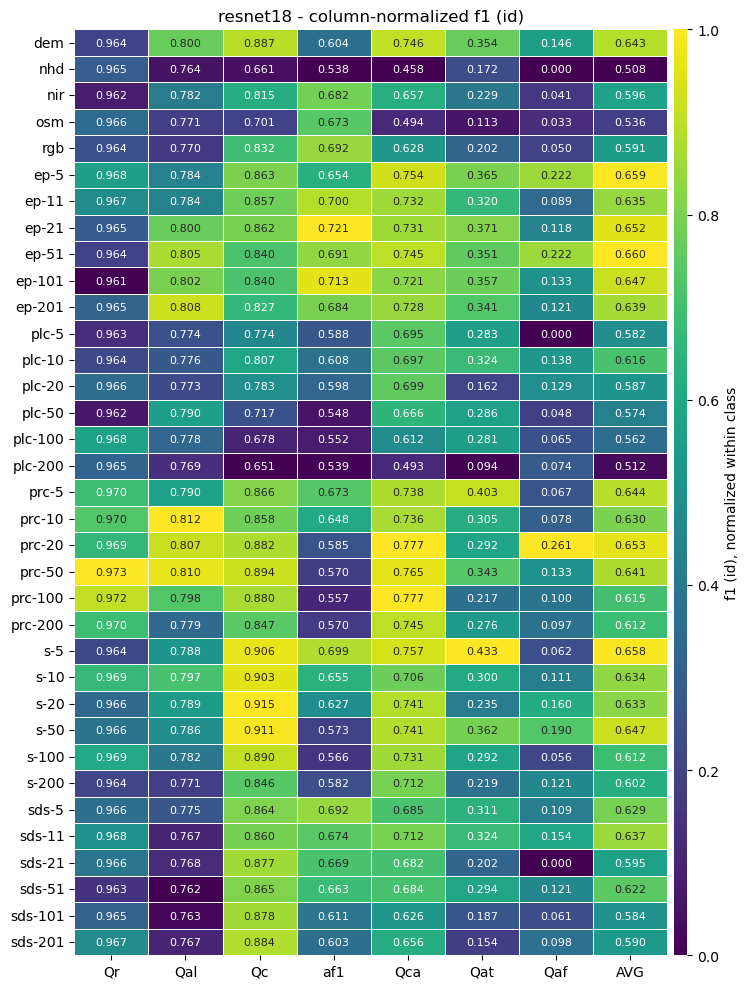

In [4]:

class_path = os.path.join(f"{ASSETS_DIR}/baselines/classification/compiled_class.csv")

metric = "f1 (id)"

model = 'resnet18'


df = pd.read_csv(class_path)
df = df[df["model"] == model].copy()
df[["family", "spatial support"]] = df["input"].apply(parse_input_label)

class_order = ["Qr", "Qal", "Qc", "af1", "Qca", "Qat", "Qaf"]
heatmap_order = class_order + ["AVG"]
family_rank = {"raw": 0, "ep": 1, "plc": 2, "prc": 3, "s": 4, "sds": 5, "multi-scale": 6, "multimodal": 7}
support_families = ["ep", "plc", "prc", "s", "sds"]

df["family_rank"] = df["family"].map(family_rank)
df["support_sort"] = np.where(df["family"].isin(support_families), pd.to_numeric(df["spatial support"], errors="coerce"), np.nan)
df["alpha_sort"] = df["input"].astype(str).str.lower()
df = df.sort_values(by=["family_rank", "support_sort", "alpha_sort"], na_position="last")

row_order = df["input"].drop_duplicates()
heatmap_df = df.pivot(index="input", columns="class", values=metric).loc[row_order, class_order]
heatmap_df['AVG'] = heatmap_df[class_order].mean(axis=1)

heatmap_df = heatmap_df.loc[:'sds-201']
heatmap_norm = (heatmap_df - heatmap_df.min(axis=0)) / (heatmap_df.max(axis=0) - heatmap_df.min(axis=0))


fig, ax = plt.subplots(figsize=(8,10))

sns.heatmap(
    heatmap_norm[heatmap_order],
    annot=heatmap_df[heatmap_order],
    fmt=".3f",
    cmap="viridis",
    linewidths=0.5,
    annot_kws={'fontsize': 8},
    cbar_kws={"label": f"{metric}, normalized within class", 'pad':0.01, 'aspect':70},
    ax=ax
    )

ax.set_xlabel("")
ax.set_ylabel("")
ax.set_title(f"{model} - column-normalized {metric}")

plt.tight_layout()
plt.show()